In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge,Lasso
from sklearn.metrics import mean_squared_error, r2_score



### Generate Synthetic Data

In [71]:
X, y = make_regression(n_samples=200, n_features=1, noise=50000.0, random_state=102)

Z-Score Normalization

In [72]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

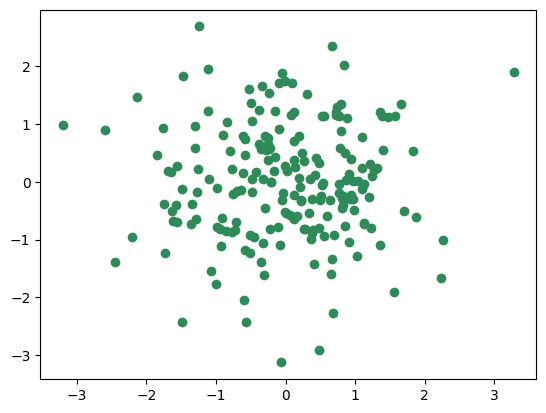

In [73]:
plt.scatter(X,y, color='seagreen')
plt.show()

# Part 1: Ridge Regression (L2 Regularization)

### Training the Ridge model on our dataset with different lambdas

In [74]:
def get_loss_slope_intercept(lam):
  regressor = Ridge(alpha=lam)
  regressor.fit(X,y)
  predictions = regressor.predict(X)
  ssr = mean_squared_error(y, predictions) * len(y)
  total_loss = ssr + lam * (regressor.coef_**2).sum()
  # print('Slope: ', regressor.coef_[0])
  # print('Intercept: ', regressor.intercept_)
  return total_loss, regressor.coef_[0], regressor.intercept_



### Visualization
#### Loss = Sum of Squared Residuals + lambda*(the slope)^2
#### As lambda increases the slope decreases. In case of Ridge Regression, the slope never reaches zero.

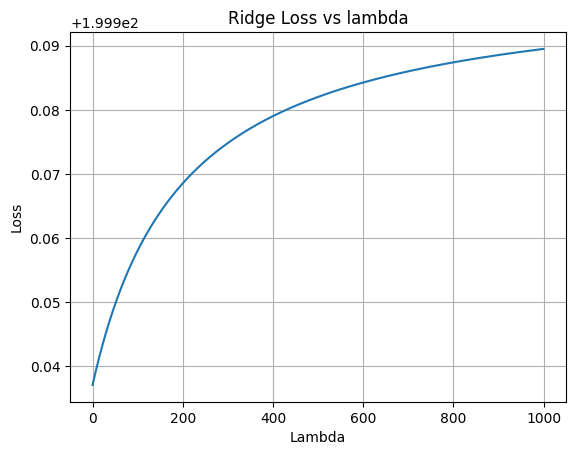

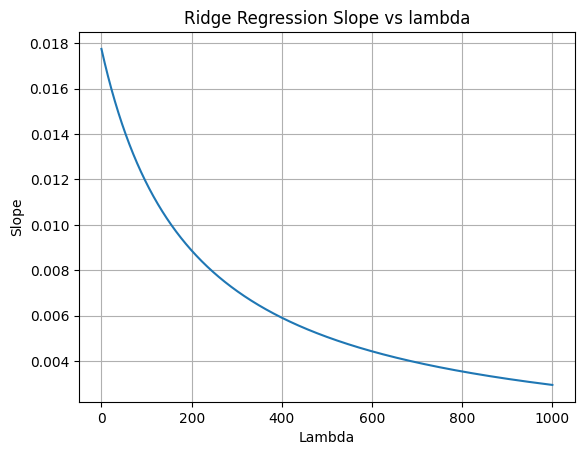

In [75]:
l = []
losses = []
slopes = []

for lam in np.arange(0,1000,0.1):
  l.append(lam)
  loss,slope,intercept = get_loss_slope_intercept(lam)
  losses.append(loss)
  slopes.append(slope)

plt.plot(l,losses)
plt.grid(True)
plt.xlabel('Lambda')
plt.ylabel('Loss')
plt.title('Ridge Loss vs lambda')
plt.show()

plt.plot(l,slopes)
plt.grid(True)
plt.xlabel('Lambda')
plt.ylabel('Slope')
plt.title('Ridge Regression Slope vs lambda')
plt.show()

### Function to generate Slope vs Loss for a constant lambda
##### In the previous section, we saw slope vs lambda curve, those values of slope for each constant lambda were optimal which means the combination of (slope and lambda) gave the least "Loss". However in this case we plot slope vs lambda by varying slope from the optimal slope point by 1000 units in both direction.

In [76]:
def get_loss_vs_slope(lam, color):
  _, optimal_slope, opt_intercept = get_loss_slope_intercept(lam)

  slope_range = np.linspace(optimal_slope - 0.05, optimal_slope + 0.05, 100)
  custom_losses = []


  for s in slope_range:
    preds = (X * s) + opt_intercept
    ssr = mean_squared_error(y, preds.flatten()) * len(y)
    penalty = lam * (s**2)
    custom_losses.append(ssr + penalty)


  plt.plot(slope_range, custom_losses, color=color, label=f'Loss (Lambda={lam})')
  plt.axvline(optimal_slope, color=color, linestyle='--', label=f'Optimal Slope: {optimal_slope:.2f}')

### Plotting

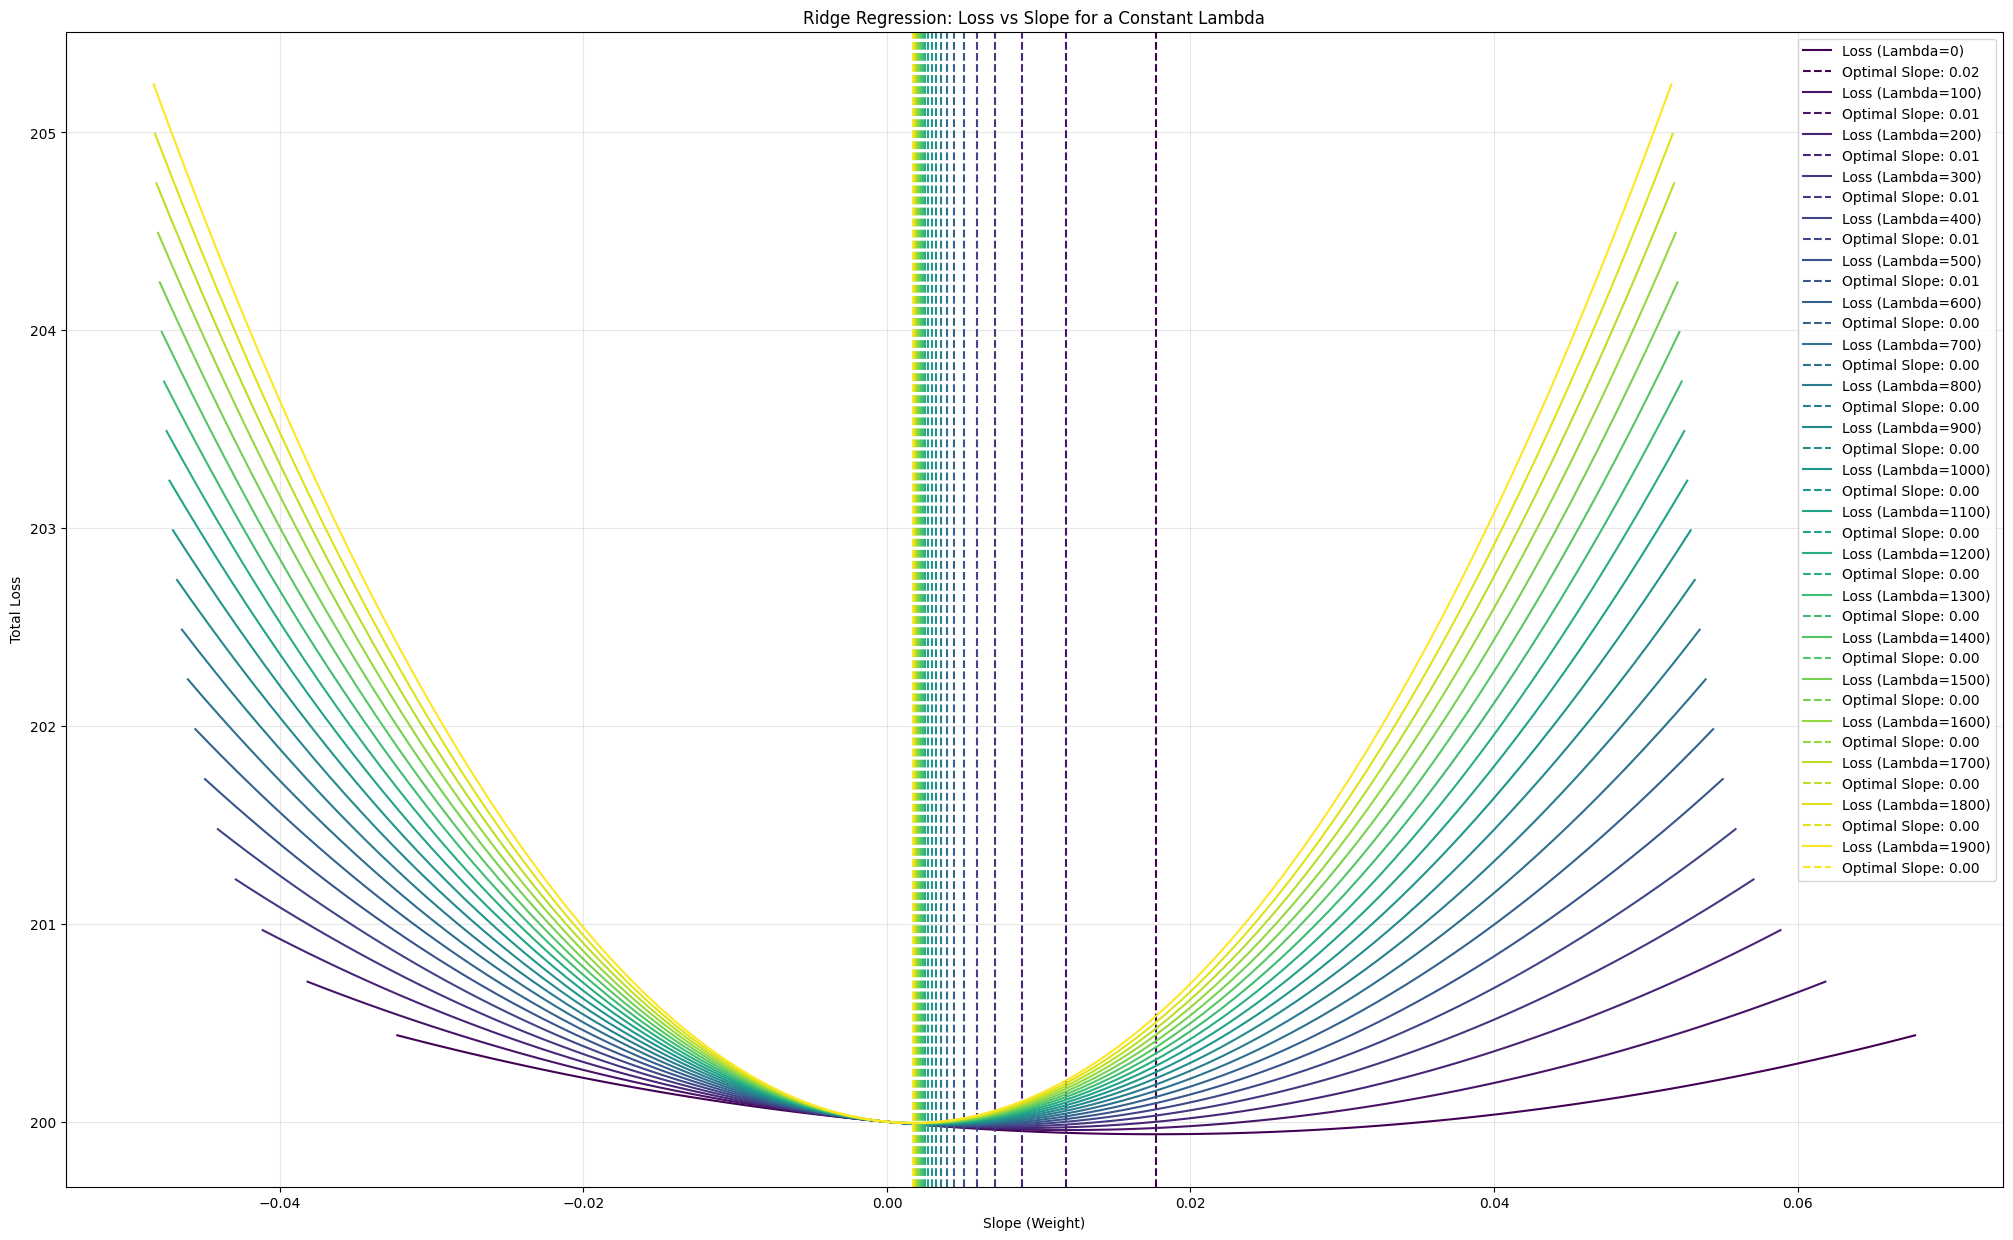

In [77]:
lambdas = np.arange(0,2000,100)
colors = cm.viridis(np.linspace(0, 1, len(lambdas)))




plt.figure(figsize=(25, 15))
for lam, color in zip(lambdas, colors):
  get_loss_vs_slope(lam, color)
plt.xlabel('Slope (Weight)')
plt.ylabel('Total Loss')
plt.title('Ridge Regression: Loss vs Slope for a Constant Lambda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Part 2: Lasso Regression (L1 Regularization)

Training the Lasso model on our dataset with different lambdas

In [78]:
def get_loss_slope_intercept_lasso(lam):
  regressor = Lasso(alpha=lam)
  regressor.fit(X,y)
  predictions = regressor.predict(X)
  ssr = mean_squared_error(y, predictions) * len(y)
  total_loss = ssr + lam * abs(regressor.coef_).sum()
  # print('Slope: ', regressor.coef_[0])
  # print('Intercept: ', regressor.intercept_)
  return total_loss, regressor.coef_[0], regressor.intercept_

### Visualization
##### Loss = Sum of Squared Residuals + lambda*|the slope|
##### As lambda increases the slope decreases. In case of Lasso Regression, the slope actually reaches zero.

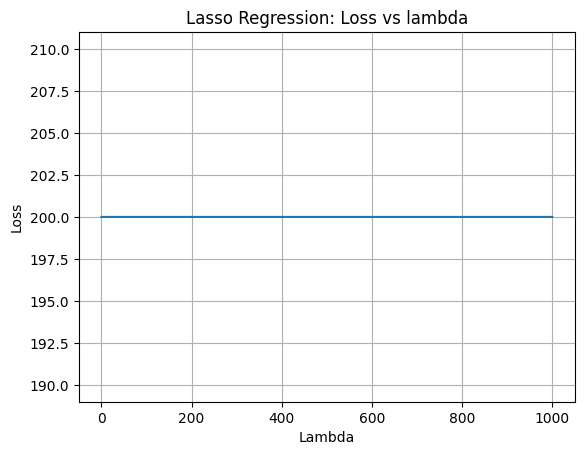

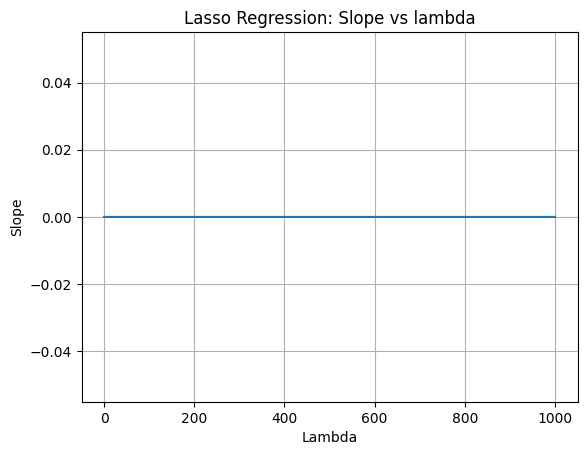

In [79]:
l = []
losses = []
slopes = []

for lam in np.arange(0.1,1000,0.1):
  l.append(lam)
  loss,slope,intercept = get_loss_slope_intercept_lasso(lam)
  losses.append(loss)
  slopes.append(slope)

plt.plot(l,losses)
plt.grid(True)
plt.xlabel('Lambda')
plt.ylabel('Loss')
plt.title('Lasso Regression: Loss vs lambda')
plt.show()

plt.plot(l,slopes)
plt.grid(True)
plt.xlabel('Lambda')
plt.ylabel('Slope')
plt.title('Lasso Regression: Slope vs lambda')
plt.show()

### Function to generate Slope vs Loss for a constant lambda
##### In the previous section, we saw slope vs lambda curve, those values of slope for each constant lambda were optimal which means the combination of (slope and lambda) gave the least "Loss". However in this case we plot slope vs lambda by varying slope from the optimal slope point by 0.05 units in both direction.

In [80]:
def get_loss_vs_slope_lasso(lam, color):
  _, optimal_slope, opt_intercept = get_loss_slope_intercept_lasso(lam)

  slope_range = np.linspace(optimal_slope - 0.05, optimal_slope + 0.05, 100)
  custom_losses = []


  for s in slope_range:
    preds = (X * s) + opt_intercept
    ssr = mean_squared_error(y, preds.flatten()) * len(y)
    penalty = lam * abs(s)
    custom_losses.append(ssr + penalty)


  plt.plot(slope_range, custom_losses, color=color, label=f'Loss (Lambda={lam})')
  plt.axvline(optimal_slope, color=color, linestyle='--', label=f'Optimal Slope: {optimal_slope:.2f}')

### Plotting

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(


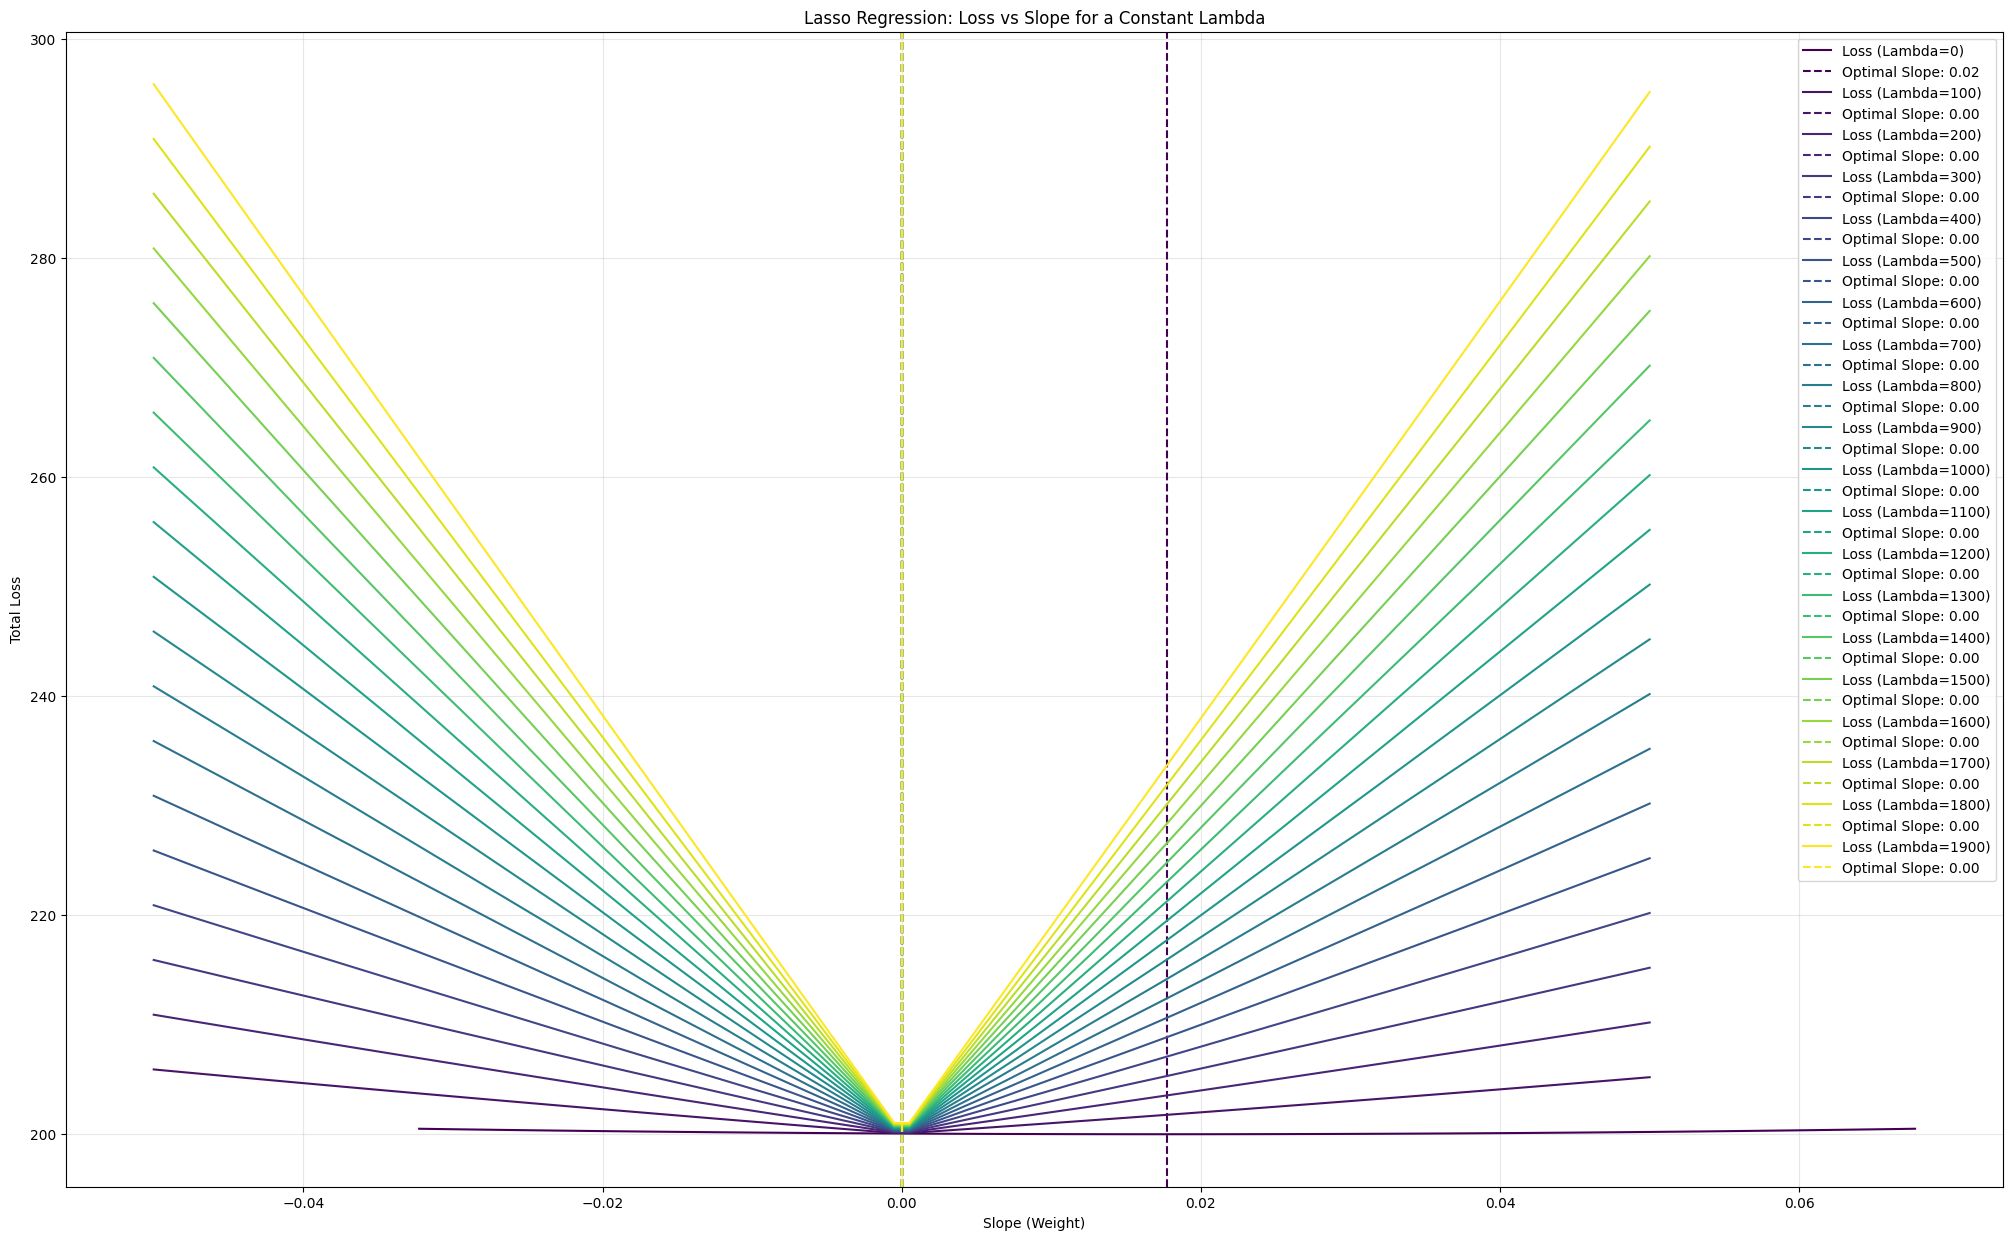

In [81]:
lambdas = np.arange(0,2000,100)
colors = cm.viridis(np.linspace(0, 1, len(lambdas)))


plt.figure(figsize=(25, 15))
for lam, color in zip(lambdas, colors):
  get_loss_vs_slope_lasso(lam, color)
plt.xlabel('Slope (Weight)')
plt.ylabel('Total Loss')
plt.title('Lasso Regression: Loss vs Slope for a Constant Lambda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()